# 😊 Clustering Project

# Projenin Amacı

Bu projede müşteri verileri üzerinde kümeleme (clustering) analizi gerçekleştirilecektir.

Amaç benzer özelliklere sahip müşteri gruplarını belirlemek ve veri içerisindeki gizli yapıları ortaya çıkarmaktır.

Bu proje kapsamında:

- Veri temizleme
- Veri görselleştirme
- Ölçeklendirme
- K-Means Clustering
- Küme analizi

uygulanacaktır.

In [1]:
# Gerekli kütüphaneleri içe aktarıyoruz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Mall Customer datasetini KaggleHub ile indiriyoruz

import kagglehub

dataset_path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print(dataset_path)

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python


In [3]:
# Dataset dosyalarını kontrol ediyoruz

import os

print(os.listdir(dataset_path))

['Mall_Customers.csv']


In [4]:
# CSV dosyasını okuyoruz

df = pd.read_csv(dataset_path + "/Mall_Customers.csv")

print(df.shape)

df.head()

(200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 📊 Veri Analizi ve Görselleştirme

Bu bölümde müşteri verileri incelenecek ve kümelenme yapısına uygun dağılımlar analiz edilecektir.

In [5]:
# Veri tipi ve eksik veri kontrolü

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# Eksik veri kontrolü

df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
# Sayısal istatistikleri inceliyoruz

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


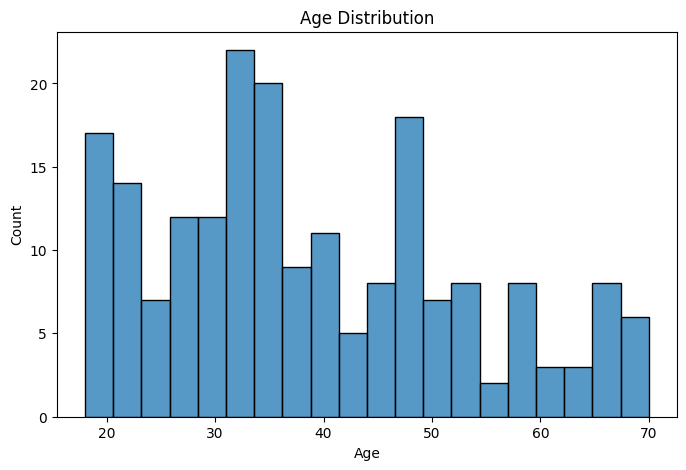

In [8]:
# Yaş dağılımını görselleştiriyoruz

plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

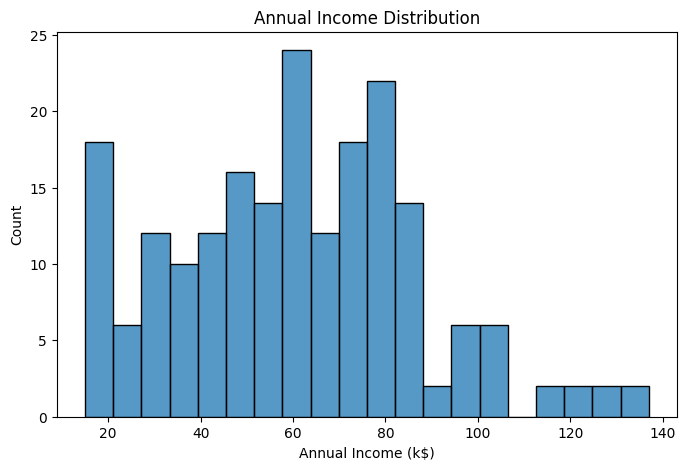

In [9]:
# Gelir dağılımını görselleştiriyoruz

plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=20)

plt.title("Annual Income Distribution")

plt.show()

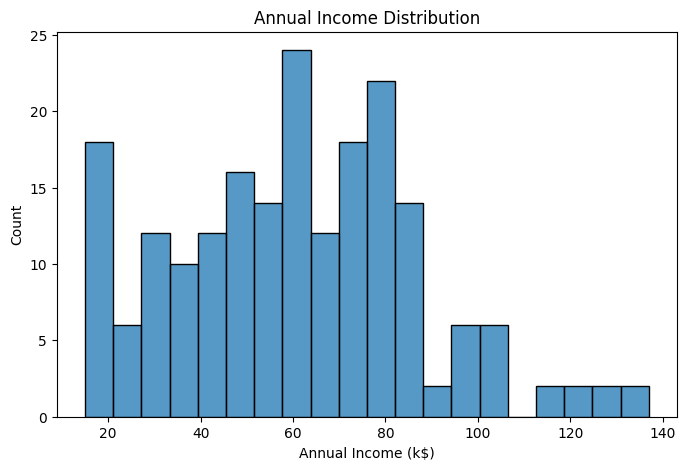

In [10]:
# Gelir dağılımını görselleştiriyoruz

plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=20)

plt.title("Annual Income Distribution")

plt.show()

# 🎯 Clustering İçin Veri Hazırlama

Bu bölümde müşteri kümelerini oluşturmak için gelir ve harcama skorları kullanılacaktır.

In [11]:
# Clustering için gerekli sütunları seçiyoruz

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [12]:
# Elbow yöntemi ile ideal cluster sayısını buluyoruz

wcss = []

for i in range(1,11):
    
    kmeans = KMeans(n_clusters=i, random_state=42)
    
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

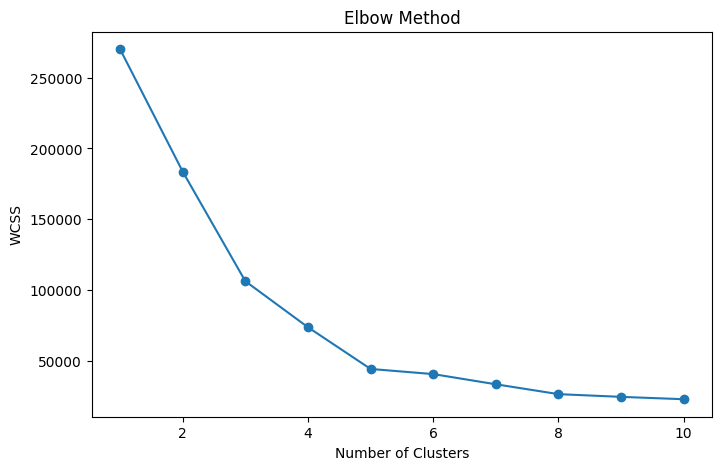

In [13]:
# Elbow grafiğini çiziyoruz

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [14]:
# KMeans modelini oluşturuyoruz

kmeans = KMeans(n_clusters=5, random_state=42)

y_kmeans = kmeans.fit_predict(X)

y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

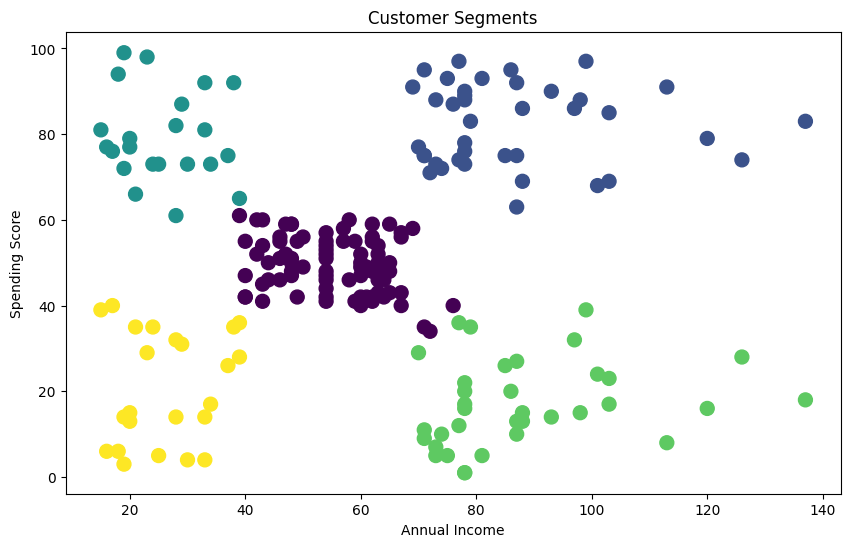

In [15]:
# Cluster sonuçlarını görselleştiriyoruz

plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap="viridis",
    s=100
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segments")

plt.show()

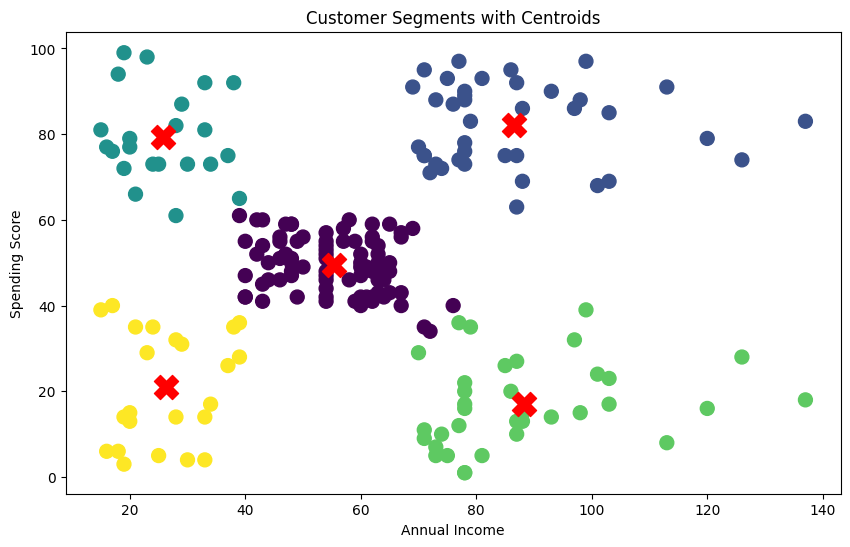

In [16]:
# Cluster merkezlerini görselleştiriyoruz

plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap="viridis",
    s=100
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c="red",
    marker="X"
)

plt.xlabel("Annual Income")

plt.ylabel("Spending Score")

plt.title("Customer Segments with Centroids")

plt.show()

# ✅ Proje Sonuçları

Bu projede Mall Customer veri seti kullanılarak müşteri segmentasyonu gerçekleştirilmiştir.

Veri analizi ve görselleştirme işlemleri yapıldıktan sonra müşterilerin gelir ve harcama davranışları incelenmiştir.

Projede K-Means Clustering algoritması kullanılmıştır.

Elbow yöntemi ile en uygun cluster sayısının 5 olduğu gözlemlenmiştir.

Model sonucunda müşteriler farklı segmentlere ayrılmış ve benzer davranış gösteren müşteri grupları belirlenmiştir.

Bu proje sayesinde:

- Veri analizi
- Veri görselleştirme
- Unsupervised Learning
- K-Means Clustering
- Customer Segmentation

uygulanmıştır.